# Setup

In [3]:
import numpy as np
import pandas as pd

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve)

import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import zipfile

In [4]:
uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
zip_file = [f for f in uploaded.keys() if f.lower().endswith(".zip")][0]

extract_dir = "/content/telco_data"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

csv_files = glob.glob(
    os.path.join(extract_dir, "**", "*.csv"),
    recursive=True)

data = pd.read_csv(csv_files[0])

In [6]:
# clean column names
data.columns = data.columns.str.strip()

# TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce")

# binary outcome
data["Churn_binary"] = data["Churn"].map({
    "No": 0,
    "Yes": 1})

# remove rows with missing values
data = data.dropna().copy()

print("Cleaned dataset shape:", data.shape)
display(data.head())

Cleaned dataset shape: (7032, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


# Logistic Regression

## Binary Assumption

In [7]:
print("Churn counts:")
display(data["Churn_binary"].value_counts())

print("\nChurn proportions:")
display(data["Churn_binary"].value_counts(normalize=True))

Churn counts:


,count
Churn_binary,
0,5163
1,1869



Churn proportions:


,proportion
Churn_binary,
0,0.734215
1,0.265785


The outcome is binary, with 0 representing customers who didn't churn and 1 representing customers who churned.

In [8]:
print("Binary assumption is validated")

Binary assumption is validated


## Accuracy Measure

In [9]:
X = data.drop(columns=["Churn", "Churn_binary", "customerID"], errors="ignore")
print("Predictor shape:", X.shape)

y = data["Churn_binary"]
print("Outcome shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())

Predictor shape: (7032, 19)
Outcome shape: (7032,)
Training set: (5625, 19)
Test set: (1407, 19)

Training churn rate: 0.2657777777777778
Test churn rate: 0.2658137882018479


In [10]:
# numeric and categorical predictors

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]).columns.tolist()

print("Numeric variables:")
print(numeric_features)

print("\nCategorical variables:")
print(categorical_features)

Numeric variables:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical variables:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features)
    ]
)

In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
            LogisticRegression(
                max_iter=2000))
    ]
)

In [13]:
logistic_model.fit(
    X_train,
    y_train)

print("Logistic regression fitted")

Logistic regression fitted


In [14]:
y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:  {accuracy:.3f}")

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.3f}")

recall = recall_score(y_test, y_pred)
print(f"Recall:    {recall:.3f}")

f1 = f1_score(y_test, y_pred)
print(f"F1 Score:  {f1:.3f}")

# predicted probability of class 1
y_prob = logistic_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC:   {roc_auc:.3f}")

Accuracy:  0.805
Precision: 0.652
Recall:    0.575
F1 Score:  0.611
ROC-AUC:   0.836


### Accuracy of Logistic Reg: 80.5%

Approximately 80.5% accuracy and 0.836 ROC-AUC, which indicates useful predictive discrimination

### ROC Curve
y-axis: recall/sensitivity

High curve = higher AUC = better ability to distinguish the two classes

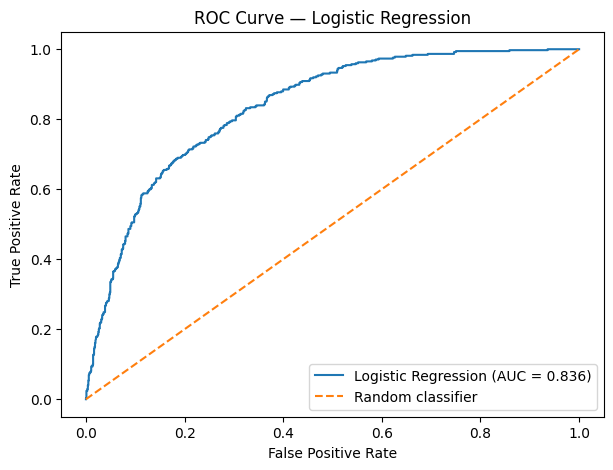

In [15]:
# calc ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})")

# random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()

The ROC curve evaluates model discrimination across classification thresholds. An AUC of approximately 0.836 indicates that the model has reasonably strong ability to distinguish customers who churn from those who don't.

## Assumption Checks

In [19]:
# categorical variables to dummy variables
X_train_sm = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True,
    dtype=float)

X_test_sm = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True,
    dtype=float)

# ensure train and test have identical columns
X_test_sm = X_test_sm.reindex(
    columns=X_train_sm.columns,
    fill_value=0)

### Indepndence Assumption

Know that the dataset doesn't contain duplicate customer IDs.

In [20]:
original_data = pd.read_csv(csv_files[0])
original_data.columns = original_data.columns.str.strip()

print("Number of rows:", len(original_data))
print("Unique customer IDs:", original_data["customerID"].nunique())
print(
    "Duplicate customer IDs:",
    original_data["customerID"].duplicated().sum())

Number of rows: 7043
Unique customer IDs: 7043
Duplicate customer IDs: 0


The dataset contains one observation per customer and no duplicate customer IDs, providing substantive support for treating observations as independent.

### No Perfect Seperation Assumption


In [24]:
for col in categorical_features:
    print(f"\n===== {col} =====")
    display(
        pd.crosstab(
            data[col],
            data["Churn_binary"])
    )

# No categories with zero churners or zero non-churners- indicating no perfect seperation
print('No Perfect Seperation Assumption Confirmed')


===== gender =====


Churn_binary,0,1
gender,,
Female,2544,939
Male,2619,930



===== Partner =====


Churn_binary,0,1
Partner,,
No,2439,1200
Yes,2724,669



===== Dependents =====


...


===== PaperlessBilling =====


Churn_binary,0,1
PaperlessBilling,,
No,2395,469
Yes,2768,1400



===== PaymentMethod =====


Churn_binary,0,1
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


No Perfect Seperation Assumption Confirmed
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


The categorical predictors were examined using cross-tabulations of each category against churn to identify potential perfect separation. No categories with zero observations in one outcome class were identified, providing evidence that the fitted model didn't encounter problematic perfect separation.

### Linearity in log-odds Assumption

In [27]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_sm)
X_test_sm = sm.add_constant(X_test_sm)

logit_model = sm.Logit(y_train,X_train_sm)
logit_result = logit_model.fit()

positive_numeric = [
    col for col in numeric_features
    if (data[col] > 0).all()]
X_bt = X_train_sm.copy()

for col in positive_numeric:
    X_bt[f"{col}_log_interaction"] = (
        X_bt[col] * np.log(X_bt[col]))

Optimization terminated successfully.
         Current function value: 0.411329
         Iterations 9


In [28]:
box_tidwell_model = sm.Logit(
    y_train,
    X_bt)

box_tidwell_result = box_tidwell_model.fit()
print(box_tidwell_result.summary())

Optimization terminated successfully.
         Current function value: 0.404850
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           Churn_binary   No. Observations:                 5625
Model:                          Logit   Df Residuals:                     5598
Method:                           MLE   Df Model:                           26
Date:                Fri, 04 Sep 2026   Pseudo R-squ.:                  0.3008
Time:                        18:13:14   Log-Likelihood:                -2277.3
converged:                       True   LL-Null:                       -3257.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     3.1864   3.3

In [ ]:
bt_terms = [
    col for col in X_bt.columns
    if col.endswith("_log_interaction")]

print(box_tidwell_result.pvalues[bt_terms])
print("For each X log (x) term, there is evidence that the predictor's relationship with the log-odds is nonlinear.")

In [ ]:
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_bt = X_train_sm.copy()

for col in continuous_features:
    X_bt[f"{col}_log_interaction"] = (
        X_bt[col] *
        np.log(X_bt[col] + 1e-6)
    )

box_tidwell_model = sm.Logit(
    y_train,
    X_bt
)

box_tidwell_result = box_tidwell_model.fit(
    disp=False
)

bt_terms = [
    col
    for col in X_bt.columns
    if col.endswith("_log_interaction")
]

bt_results = pd.DataFrame({
    "Term": bt_terms,
    "p_value": [
        box_tidwell_result.pvalues[col]
        for col in bt_terms
    ]
})

display(bt_results)

In [ ]:
for _, row in bt_results.iterrows():
    if row["p_value"] < 0.05:
        print(
            f"{row['Term']}: p = {row['p_value']:.4f} "
            "→ evidence of nonlinearity"
        )
    else:
        print(
            f"{row['Term']}: p = {row['p_value']:.4f} "
            "→ no significant evidence of nonlinearity"
        )

The Box-Tidwell test evaluates whether continuous predictors have a linear relationship with the log-odds of churn. Some continuous predictors violate this assumption here, but logistic regression could still be useful.

### Multicollinearity Assumption

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train_sm.drop(
    columns=["const"])

vif_results = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values,i)
        for i in range(X_vif.shape[1])]
})

vif_results = vif_results.sort_values("VIF", ascending=False)
high_vif = vif_results[vif_results["VIF"] > 5]

print("Features with VIF > 5:")
display(high_vif)

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Features with VIF > 5:


,Feature,VIF
11,InternetService_No,inf
12,OnlineSecurity_No internet service,inf
18,TechSupport_No internet service,inf
20,StreamingTV_No internet service,inf
16,DeviceProtection_No internet service,inf
14,OnlineBackup_No internet service,inf
22,StreamingMovies_No internet service,inf
7,PhoneService_Yes,1775.332634
2,MonthlyCharges,870.239464
10,InternetService_Fiber optic,149.279541


several large VIF concerning, values


Many elevated VIF values, which will be an interpretability concern, but not automatically a reason to reject logistic regression.

### Sample Size Assumption

In [30]:
events = y_train.sum()
non_events = (y_train == 0).sum()

X_train_transformed = (
    logistic_model
    .named_steps["preprocessor"]
    .transform(X_train))
n_parameters = X_train_transformed.shape[1]

epv = events / n_parameters

print("Churn events:", int(events))
print("Non-events:", int(non_events))
print("Model parameters:", n_parameters)
print("Events per parameter:",
    round(epv, 2))

Churn events: 1495
Non-events: 4130
Model parameters: 30
Events per parameter: 49.83


Events per variable: 49.83- a sufficiently large sample size.

## Coefficients

In [35]:
preprocessor_fitted = logistic_model.named_steps["preprocessor"]

# names of the transformed features
feature_names = preprocessor_fitted.get_feature_names_out()

# logistic regression coefficients
coefficients = logistic_model.named_steps["classifier"].coef_[0]

# dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients})

# odds ratio
coef_df["Odds_Ratio"] = np.exp(
    coef_df["Coefficient"])

# add absolute coefficient for sorting
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# sort by magnitude
coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=True)

odds_ratio_df = coef_df[
    ["Feature", "Coefficient", "Odds_Ratio"]
].sort_values(
    "Coefficient",
    ascending=False)

display(odds_ratio_df)

,Feature,Coefficient,Odds_Ratio
10,categorical__InternetService_Fiber optic,1.107407,3.026501
3,numeric__TotalCharges,0.645508,1.906955
28,categorical__PaymentMethod_Electronic check,0.379150,1.461042
21,categorical__StreamingTV_Yes,0.372407,1.451224
9,categorical__MultipleLines_Yes,0.362784,1.437325
23,categorical__StreamingMovies_Yes,0.344649,1.411495
26,categorical__PaperlessBilling_Yes,0.290931,1.337673
17,categorical__DeviceProtection_Yes,0.074264,1.077091
29,categorical__PaymentMethod_Mailed check,0.072700,1.075407
0,numeric__SeniorCitizen,0.072159,1.074826


Given categorical variable 'InternetService_Fiber optic', for example, the odds of churn are approximately 3.03 times higher, holding the other variables constant.

In [ ]:
plt.figure(figsize=(10, 9))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"])

plt.axvline(
    0,
    linestyle="--")

plt.xlabel("Log-Odds Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")

plt.tight_layout()
plt.show()

The largest postive or negative impact on churn is by variables: 'categorical__gender_Male', 'categorical__Partner_Yes', 'categorical__PaymentMethod_Credit card (automatic)', 'numeric__SeniorCitizen', and 'categorical__PaymentMethod_Mailed check'.

Because numeric predictors were standardized, their coefficients represent a one-standard-deviation increase.
Categorical coefficients compare each displayed category with its omitted reference category.  